# Streaming

## Review

In module 2, covered a few ways to customize graph state and memory.

We built up to a Chatbot with external memory that can sustain long-running conversations.

## Goals

This module will dive into `human-in-the-loop`, which builds on memory and allows users to interact directly with graphs in various ways.

To set the stage for `human-in-the-loop`, we'll first dive into **streaming**, which provides several ways to visualize graph output (e.g., node state or chat model tokens) over the course of execution.

## Streaming

LangGraph is built with [first class support for streaming](https://docs.langchain.com/oss/python/langgraph/streaming).

Let's set up our Chatbot from Module 2, and show various way to stream outputs from the graph during execution.

In [1]:
import dotenv

dotenv.load_dotenv()

True

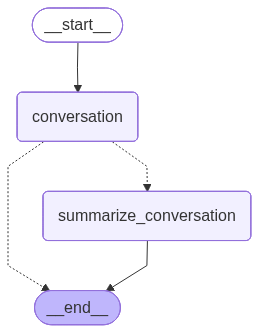

In [2]:
from IPython.display import Image, display
from typing import Literal

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage, HumanMessage, RemoveMessage
from langchain_core.runnables import RunnableConfig

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState, StateGraph, START, END

# LLM
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite", temperature=0) 

# State 
class State(MessagesState):
    summary: str

# Define the logic to call the model
def call_model(state: State, config: RunnableConfig):
    
    # Get summary if it exists
    summary = state.get("summary", "")

    # If there is summary, then we add it
    if summary:
        
        # Add summary to system message
        system_message = f"Summary of conversation earlier: {summary}"

        # Append summary to any newer messages
        messages = [SystemMessage(content=system_message)] + state["messages"]
    
    else:
        messages = state["messages"]
    
    response = model.invoke(messages, config)
    return {"messages": response}

def summarize_conversation(state: State):
    
    # First, we get any existing summary
    summary = state.get("summary", "")

    # Create our summarization prompt 
    if summary:
        
        # A summary already exists
        summary_message = (
            f"This is summary of the conversation to date: {summary}\n\n"
            "Extend the summary by taking into account the new messages above:"
        )
        
    else:
        summary_message = "Create a summary of the conversation above:"

    # Add prompt to our history
    messages = state["messages"] + [HumanMessage(content=summary_message)]
    response = model.invoke(messages)
    
    # Delete all but the 2 most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"summary": response.content, "messages": delete_messages}

# Determine whether to end or summarize the conversation
def should_continue(state: State)-> Literal ["summarize_conversation",END]:
    
    """Return the next node to execute."""
    
    messages = state["messages"]
    
    # If there are more than six messages, then we summarize the conversation
    if len(messages) > 6:
        return "summarize_conversation"
    
    # Otherwise we can just end
    return END

# Define a new graph
workflow = StateGraph(State)

workflow.add_node("conversation", call_model)
workflow.add_node(summarize_conversation)

# Set the entrypoint as conversation
workflow.add_edge(START, "conversation")
workflow.add_conditional_edges("conversation", should_continue)
workflow.add_edge("summarize_conversation", END)

# Compile
memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

## Streaming full state

Now, let's talk about ways to [stream our graph state](https://docs.langchain.com/oss/python/langgraph/streaming#supported-stream-modes).

`.stream` and `.astream` are sync and async methods for streaming back results.

LangGraph supports a few [different streaming modes](https://docs.langchain.com/oss/python/langgraph/streaming#stream-graph-state) for graph state.

- `values:` This streams the full state of the graph after each node is called.
- `updates:` This streams updates to the state of the graph after each node is called.

<img width="800" src="https://camo.githubusercontent.com/96e1ee1e5157690bb07e432f92c65f80590342093fae801bdfd1179964906e2f/68747470733a2f2f63646e2e70726f642e776562736974652d66696c65732e636f6d2f3635623863643732383335636565616364343434396135332f3636646261663839326432343632356132303137343465355f73747265616d696e67312e706e67" />

Let's look at `stream_mode="updates"`.

Because we stream with `updates`, we only see updates to the state after node in the graph is run.

Each `chunk` is a dict with `node_name` as the key and the updated state as the value.

In [3]:
# Create a thread
config = {"configurable": {"thread_id": "1"}}

# Start conversation
for chunk in graph.stream({"messages": [HumanMessage(content="hi! I'm Dibyajyoti")]}, config, stream_mode="updates"):
    print(chunk)

{'conversation': {'messages': AIMessage(content="Hi Dibyajyoti! It's nice to meet you. How can I help you today?", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019dc59c-8216-7650-a9b5-faead9e82fb2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 10, 'output_tokens': 21, 'total_tokens': 31, 'input_token_details': {'cache_read': 0}})}}


In [4]:
# Start conversation
for chunk in graph.stream({"messages": [HumanMessage(content="hi! I'm Dibyajyoti")]}, config, stream_mode="updates"):
    chunk["conversation"]["messages"].pretty_print()

================================== Ai Message ==================================

Hi Dibyajyoti! It's great to meet you. What can I do for you today?


Now, we can see `stream_mode="values"`.

This is the full state of the graph after the conversation node is called.

In [5]:
# Start conversation, again
config = {"configurable": {"thread_id": "2"}}

# Start conversation
input_message = HumanMessage(content="hi! I'm Dibyajyoti")
for event in graph.stream({"messages": [input_message]}, config, stream_mode="values"):
    for m in event['messages']:
        m.pretty_print()
    print("---"*25)

================================ Human Message =================================

hi! I'm Dibyajyoti
---------------------------------------------------------------------------
================================ Human Message =================================

hi! I'm Dibyajyoti
================================== Ai Message ==================================

Hi Dibyajyoti! It's nice to meet you. How can I help you today?
---------------------------------------------------------------------------


## Streaming tokens

We often want to stream more than graph state. In particular, with chat model calls it is common to stream the tokens as they are generated.

We can do this using the `.astream_events` method, which streams back events as they happen inside nodes!

Each event is a dict with a few keys:

- `event`: This is the type of event that is being emitted.
- `name`: This is the name of event.
- `data`: This is the data associated with the event.
- `metadata`: Contains langgraph_node, the node emitting the event.

Let's have a look.

In [6]:
config = {"configurable": {"thread_id": "3"}}

input_message = HumanMessage(content="Tell me about the best Kanto starter Pokemon?")

async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    print(f"Node: {event['metadata'].get('langgraph_node','')}. Type: {event['event']}. Name: {event['name']}")

Node: . Type: on_chain_start. Name: LangGraph
Node: conversation. Type: on_chain_start. Name: conversation
Node: conversation. Type: on_chat_model_start. Name: ChatGoogleGenerativeAI
Node: conversation. Type: on_chat_model_stream. Name: ChatGoogleGenerativeAI
Node: conversation. Type: on_chat_model_stream. Name: ChatGoogleGenerativeAI
Node: conversation. Type: on_chat_model_stream. Name: ChatGoogleGenerativeAI
Node: conversation. Type: on_chat_model_stream. Name: ChatGoogleGenerativeAI
Node: conversation. Type: on_chat_model_stream. Name: ChatGoogleGenerativeAI
Node: conversation. Type: on_chat_model_stream. Name: ChatGoogleGenerativeAI
Node: conversation. Type: on_chat_model_stream. Name: ChatGoogleGenerativeAI
Node: conversation. Type: on_chat_model_stream. Name: ChatGoogleGenerativeAI
Node: conversation. Type: on_chat_model_stream. Name: ChatGoogleGenerativeAI
Node: conversation. Type: on_chat_model_stream. Name: ChatGoogleGenerativeAI
Node: conversation. Type: on_chat_model_stream.

**The central point is that tokens from chat models within your graph have the `on_chat_model_stream` type.**

We can use `event['metadata']['langgraph_node']` to select the node to stream from.

And we can use `event['data']` to get the actual data for each event, which in this case is an `AIMessageChunk`.

In [7]:
node_to_stream = 'conversation'

config = {"configurable": {"thread_id": "4"}}

input_message = HumanMessage(content="Tell me about the best Kanto starter Pokemon?")

async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    # Get chat model tokens from a particular node 
    if event["event"] == "on_chat_model_stream" and event['metadata'].get('langgraph_node','') == node_to_stream:
        print(event["data"])

{'chunk': AIMessageChunk(content='Ah', additional_kwargs={}, response_metadata={'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019dc5a4-6013-77a1-95bc-bf44540b2780', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 1, 'total_tokens': 12, 'input_token_details': {'cache_read': 0}}, tool_call_chunks=[])}
{'chunk': AIMessageChunk(content=', the Kanto starters! A classic debate that has fueled countless playground arguments and online', additional_kwargs={}, response_metadata={'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019dc5a4-6013-77a1-95bc-bf44540b2780', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 0, 'total_tokens': 17, 'input_token_details': {'cache_read': 0}, 'output_tokens': 17}, tool_call_chunks=[])}
{'chunk': AIMessageChunk(content=' discussions for decades. There\'s no single "best" Kanto starter, as it truly depends on your playstyle, the challenges you anticipate, a

As you see above, just use the chunk key to get the `AIMessageChunk`.

In [8]:
node_to_stream = 'conversation'

config = {"configurable": {"thread_id": "5"}}

input_message = HumanMessage(content="Tell me about the best Kanto starter Pokemon?")

async for event in graph.astream_events({"messages": [input_message]}, config, version="v2"):
    # Get chat model tokens from a particular node 
    if event["event"] == "on_chat_model_stream" and event['metadata'].get('langgraph_node','') == node_to_stream:
        data = event["data"]
        print(data["chunk"].content, end="|")

Ah|, the Kanto starters! A classic debate that has fueled countless playground arguments and online| discussions for decades. There's no single "best" Kanto starter, as it truly depends on your playstyle, the challenges you anticipate, and even a bit of personal preference. However, we can definitely break down the strengths and weaknesses of each to| help you decide who reigns supreme in your heart (and your team).

Let's dive into each of them:

## Bulbasaur (Grass/Poison)

*   **The Early Game King:** Bulbasaur is widely| considered the **easiest starter to use in the early game of Red, Blue, and Yellow (and their remakes).** Its Grass typing gives it a significant advantage against the first two Gym Leaders: Brock (Rock) and Misty (Water).| This allows you to breeze through the initial challenges and build a strong foundation for your team.
*   **Strengths:**
    *   **Excellent early-game coverage:** As mentioned, Brock and Misty are pushovers.
    *|   **Good defensive typing:** 

## Streaming with LangGraph API

In [9]:
from langgraph_sdk import get_client

# This is the URL of the local development server
URL = "http://127.0.0.1:2024"
client = get_client(url=URL)

# Search all hosted graphs
assistants = await client.assistants.search()

In [10]:
assistants

[{'assistant_id': 'fe096781-5601-53d2-b2f6-0d3403f7e9ca',
  'graph_id': 'agent',
  'config': {},
  'context': {},
  'metadata': {'created_by': 'system'},
  'name': 'agent',
  'created_at': '2026-04-25T17:23:06.320200+00:00',
  'updated_at': '2026-04-25T17:23:06.320200+00:00',
  'version': 1,
  'description': None}]

In [11]:
# Create a new thread
thread = await client.threads.create()

# Input message
input_message = HumanMessage(content="Multiply 2 and 3")

async for event in client.runs.stream(thread["thread_id"], 
                                      assistant_id="agent", 
                                      input={"messages": [input_message]}, 
                                      stream_mode="values"):
    print(event)

StreamPart(event='metadata', data={'run_id': '019dc5ae-241d-7323-8fc8-49308f0a02d4', 'attempt': 1}, id=None)
StreamPart(event='values', data={'messages': [{'content': 'Multiply 2 and 3', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'human', 'name': None, 'id': 'e8cb8479-058d-45e0-93f0-86dc2ba59952'}]}, id=None)
StreamPart(event='values', data={'messages': [{'content': 'Multiply 2 and 3', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'human', 'name': None, 'id': 'e8cb8479-058d-45e0-93f0-86dc2ba59952'}, {'content': '', 'additional_kwargs': {'function_call': {'name': 'multiply', 'arguments': '{"a": 2, "b": 3}'}}, 'response_metadata': {'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, 'type': 'ai', 'name': None, 'id': 'lc_run--019dc5ae-281d-7821-9c10-4f135e3c2dbf-0', 'tool_calls': [{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': '6191d6de-74c1-4c31-84f4-c1aecc09e48f', 'type': 'tool_call'}],

The streamed objects have:

- `event`: Type
- `data`: State

In [12]:
from langchain_core.messages import convert_to_messages

thread = await client.threads.create()

input_message = HumanMessage(content="Multiply 2 and 3")

async for event in client.runs.stream(thread["thread_id"], assistant_id="agent", input={"messages": [input_message]}, stream_mode="values"):
    messages = event.data.get('messages',None)
    if messages:
        print(convert_to_messages(messages)[-1])
    print('='*25)

content='Multiply 2 and 3' additional_kwargs={} response_metadata={} id='1fc22807-1fc5-409a-9aa5-0dacd92b3555'
content='' additional_kwargs={'invalid_tool_calls': [], 'usage_metadata': {'input_tokens': 169, 'output_tokens': 18, 'total_tokens': 187, 'input_token_details': {'cache_read': 0}}, 'function_call': {'name': 'multiply', 'arguments': '{"a": 2, "b": 3}'}} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--019dc5af-d2bc-7a03-aa1f-9ef10479ac28-0' tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': '657ac631-f494-44e4-8e21-1df6dc07b384', 'type': 'tool_call'}] invalid_tool_calls=[]
content='6' name='multiply' id='00412e5a-128a-490f-81c3-a84812ed8765' tool_call_id='657ac631-f494-44e4-8e21-1df6dc07b384'
content='The answer is 6.' additional_kwargs={'invalid_tool_calls': [], 'usage_metadata': {'input_tokens': 200, 'output_tokens': 6, 'total_tokens': 206, 'input_token_details'

There are some new streaming mode that are only supported via the API.

For example, we can use [messages mode](https://docs.langchain.com/oss/python/langgraph/streaming#supported-stream-modes) to better handle the above case!

This mode currently assumes that you have a `messages` key in your graph, which is a list of messages. All events emitted using `messages` mode have two attributes:

- `event`: This is the name of the event
- `data`: This is data associated with the event

In [13]:
thread = await client.threads.create()

input_message = HumanMessage(content="Multiply 2 and 3")

async for event in client.runs.stream(thread["thread_id"], 
                                      assistant_id="agent", 
                                      input={"messages": [input_message]}, 
                                      stream_mode="messages"):
    print(event.event)

metadata
messages/metadata
messages/partial
messages/partial
messages/metadata
messages/complete
messages/metadata
messages/partial
messages/partial
messages/partial


We can see a few events:

- `metadata`: metadata about the run
- `messages/complete`: fully formed message
- `messages/partial`: chat model tokens

Now, let's show how to stream these messages.

We'll define a helper function for better formatting of the tool calls in messages.

In [14]:
thread = await client.threads.create()

input_message = HumanMessage(content="Multiply 2 and 3")

def format_tool_calls(tool_calls):
    """
    Format a list of tool calls into a readable string.

    Args:
        tool_calls (list): A list of dictionaries, each representing a tool call.
            Each dictionary should have 'id', 'name', and 'args' keys.

    Returns:
        str: A formatted string of tool calls, or "No tool calls" if the list is empty.

    """

    if tool_calls:
        formatted_calls = []
        for call in tool_calls:
            formatted_calls.append(
                f"Tool Call ID: {call['id']}, Function: {call['name']}, Arguments: {call['args']}"
            )
        return "\n".join(formatted_calls)
    return "No tool calls"

async for event in client.runs.stream(
    thread["thread_id"],
    assistant_id="agent",
    input={"messages": [input_message]},
    stream_mode="messages",):
    
    # Handle metadata events
    if event.event == "metadata":
        print(f"Metadata: Run ID - {event.data['run_id']}")
        print("-" * 50)
    
    # Handle partial message events
    elif event.event == "messages/partial":
        for data_item in event.data:
            # Process user messages
            if "role" in data_item and data_item["role"] == "user":
                print(f"Human: {data_item['content']}")
            else:
                # Extract relevant data from the event
                tool_calls = data_item.get("tool_calls", [])
                invalid_tool_calls = data_item.get("invalid_tool_calls", [])
                content = data_item.get("content", "")
                response_metadata = data_item.get("response_metadata", {})

                if content:
                    print(f"AI: {content}")

                if tool_calls:
                    print("Tool Calls:")
                    print(format_tool_calls(tool_calls))

                if invalid_tool_calls:
                    print("Invalid Tool Calls:")
                    print(format_tool_calls(invalid_tool_calls))

                if response_metadata and response_metadata.get("finish_reason"):
                    print(f"Response Metadata: Finish Reason - {response_metadata['finish_reason']}")                    
        print("-" * 50)

Metadata: Run ID - 019dc5d1-4eb4-76a2-b9a3-20c941843928
--------------------------------------------------
Tool Calls:
Tool Call ID: 084bc2b8-2671-448e-9b47-a4f177075479, Function: multiply, Arguments: {'a': 2, 'b': 3}
Response Metadata: Finish Reason - STOP
--------------------------------------------------
Tool Calls:
Tool Call ID: 084bc2b8-2671-448e-9b47-a4f177075479, Function: multiply, Arguments: {'a': 2, 'b': 3}
Response Metadata: Finish Reason - STOP
--------------------------------------------------
AI: The product
--------------------------------------------------
AI: The product of 2 and 3 is 6.
Response Metadata: Finish Reason - STOP
--------------------------------------------------
AI: The product of 2 and 3 is 6.
Response Metadata: Finish Reason - STOP
--------------------------------------------------
